In [1]:
import subprocess, sys

packages = [
    "liana",
    "scanpy",
    "anndata",
    "matplotlib",
    "seaborn",
    "pandas",
    "numpy",
    "plotly",
    "python-ternary",
    "adjustText",
    "decoupler",
]

for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

print("All packages installed.")

All packages installed.


In [5]:
import scanpy as sc
import anndata as ad
import pandas as pd
import os

path = "/home/uvictor/ubels26_hair_cycle/"
output = "./cell_communication_results/"
DATA_PATH = os.path.join(path, "obj_anndata.h5ad")
OUT_DIR = os.path.join(path, output)

# Load
adata = sc.read_h5ad(DATA_PATH)

In [ ]:
# --- Move SCT counts into .X ---
# .X is all zeros from the conversion; the actual expression data is in layers['counts_SCT']
adata.X = adata.layers["counts_SCT"].copy()

# Verify
X_sample = adata.X[:100, :100]
if hasattr(X_sample, "toarray"):
    X_sample = X_sample.toarray()
print(f"X now — dtype: {adata.X.dtype}, min: {X_sample.min():.4f}, "
      f"max: {X_sample.max():.4f}, mean: {X_sample.mean():.4f}")
assert X_sample.max() > 0, "ERROR: .X is still empty after layer swap"

# --- Store clean metadata columns we'll use ---
adata.obs["phase"] = pd.Categorical(
    adata.obs["orig.ident"],
    categories=["Telogen", "Catagen", "Anagen"],  # biological order
    ordered=True,
)
adata.obs["cell_type"] = adata.obs["fine_clust"].astype(str)
adata.obs["broad_type"] = adata.obs["plotting_cell_type"].astype(str)

# --- Check if data needs log-normalization ---
# SCT corrected counts are variance-stabilized but NOT log-transformed in the 
# traditional sense. LIANA+ by default expects log1p-normalized data.
# Let's check the distribution to decide.
nonzero = X_sample[X_sample > 0]
print(f"\nNon-zero value stats — median: {np.median(nonzero):.4f}, "
      f"max: {nonzero.max():.4f}, fraction zero: {(X_sample == 0).mean():.4f}")

# If SCT corrected counts contain non-integer values or values > ~20, 
# they're already transformed. If they look like integer counts (0,1,2,...), 
# we should log-normalize.
has_decimals = np.any(nonzero != np.floor(nonzero))
print(f"Contains non-integer values: {has_decimals}")
print(f"Value range suggests {'transformed' if has_decimals or nonzero.max() < 30 else 'raw counts'} data")

# --- Summary ---
print(f"\n=== Final AnnData summary ===")
print(f"Cells: {adata.n_obs}, Genes: {adata.n_vars}")
print(f"Phases: {adata.obs['phase'].value_counts().to_dict()}")
print(f"Clusters: {adata.obs['cell_type'].nunique()}")
print(f"Broad types: {adata.obs['broad_type'].value_counts().to_dict()}")

# --- Define compartments for Block D ---
BULGE_PERMANENT = ["uHF.Bulge.1", "uHF.Bulge.2", "uHF.Bulge.3", "uHF.Bulge.4"]
BULGE_ANAGEN = ["aHF.Bulge.1", "aHF.Bulge.2", "aHF.Bulge.3"]
DP_CLUSTERS = ["DP.Qui", "DP.Ind", "DP.Str", "DP.Remod", "DP.Cup"]
ALL_BULGE = BULGE_PERMANENT + BULGE_ANAGEN
ALL_FOCUS = ALL_BULGE + DP_CLUSTERS

# Cross-tab: phase x focus clusters (cell counts)
focus_mask = adata.obs["cell_type"].isin(ALL_FOCUS)
ct = pd.crosstab(adata.obs.loc[focus_mask, "phase"], 
                 adata.obs.loc[focus_mask, "cell_type"])
ct = ct.reindex(columns=[c for c in ALL_FOCUS if c in ct.columns])
print(f"\n=== Phase x Focus Cluster cell counts ===")
print(ct.to_string())

X now — dtype: float64, min: 0.0000, max: 7.0000, mean: 0.0687

Non-zero value stats — median: 1.0000, max: 7.0000, fraction zero: 0.9446
Contains non-integer values: False
Value range suggests transformed data

=== Final AnnData summary ===
Cells: 18659, Genes: 29467
Phases: {'Anagen': 10872, 'Catagen': 4667, 'Telogen': 3120}
Clusters: 44
Broad types: {'FOL': 9524, 'EPI': 5880, 'FIB': 1437, 'ENDO': 1173, 'IMM': 414, 'NC': 231}

=== Phase x Focus Cluster cell counts ===
cell_type  uHF.Bulge.1  uHF.Bulge.2  uHF.Bulge.3  uHF.Bulge.4  aHF.Bulge.1  aHF.Bulge.2  aHF.Bulge.3  DP.Qui  DP.Ind  DP.Str  DP.Remod  DP.Cup
phase                                                                                                                                         
Telogen            307          291          640          213           10            0            4      37      18      27        60       1
Catagen            342          387          204          409          242          167         

In [7]:
# SCT corrected counts are integer-valued (0–7), count-scale.
# LIANA+ scoring methods (CellPhoneDB, NATMI, etc.) expect log-normalized expression.
adata.raw = adata.copy()  # store pre-log version in .raw if needed later
sc.pp.log1p(adata)

# Verify
X_check = adata.X[:100, :100]
if hasattr(X_check, "toarray"):
    X_check = X_check.toarray()
nz = X_check[X_check > 0]
print(f"Post-log1p — min: {X_check.min():.4f}, max: {X_check.max():.4f}, "
      f"median nonzero: {np.median(nz):.4f}")

# Compute highly variable genes (LIANA+ benefits from filtering to informative genes)
# We use the full dataset here; phase-specific HVG selection would bias the comparison.
sc.pp.highly_variable_genes(adata, n_top_genes=5000, flavor="seurat_v3", 
                             layer="counts_SCT", span=0.3)

n_hvg = adata.var["highly_variable"].sum()
print(f"HVGs selected: {n_hvg}")

# Note: We do NOT subset to HVGs — LIANA+ uses its own LR database to select genes.
# The HVG flag is stored in adata.var for optional downstream use.

# Ensure gene names are strings and deduplicated
adata.var_names_make_unique()
print(f"Unique genes: {adata.n_vars}")

# Quick sanity check: verify a few known LR genes are present
lr_check = ["SPP1", "CD44", "WNT5A", "FZD1", "BMP2", "BMPR1A", 
            "FGF7", "FGFR2", "PDGFA", "PDGFRA", "EDN1", "EDNRA"]
found = [g for g in lr_check if g in adata.var_names]
missing = [g for g in lr_check if g not in adata.var_names]
print(f"\nLR gene check — found {len(found)}/{len(lr_check)}: {found}")
if missing:
    print(f"Missing: {missing}")

print("\n✓ Preprocessing complete. Ready for LIANA+.")

Post-log1p — min: 0.0000, max: 2.0794, median nonzero: 0.6931
HVGs selected: 5000
Unique genes: 29467

LR gene check — found 12/12: ['SPP1', 'CD44', 'WNT5A', 'FZD1', 'BMP2', 'BMPR1A', 'FGF7', 'FGFR2', 'PDGFA', 'PDGFRA', 'EDN1', 'EDNRA']

✓ Preprocessing complete. Ready for LIANA+.


In [10]:
import liana as li
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

# Check available methods and resources
print("Available methods:", li.mt.rank_aggregate.methods)
print("\nAvailable resources:", li.resource.show_resources())

# We use the 'consensus' resource — this is LIANA's curated union of 
# CellPhoneDB, CellChatDB, NATMI, CellTalkDB, and others.
# This directly addresses your goal of simultaneous multi-database comparison.
RESOURCE = "consensus"

# Run per phase
phases = ["Telogen", "Catagen", "Anagen"]
liana_results = {}

for phase in phases:
    print(f"\n{'='*50}")
    print(f"Running LIANA+ for: {phase}")
    print(f"{'='*50}")
    
    adata_phase = adata[adata.obs["phase"] == phase].copy()
    
    # Check cell type representation
    ct_counts = adata_phase.obs["cell_type"].value_counts()
    # Remove cell types with < 10 cells (unreliable estimates)
    valid_types = ct_counts[ct_counts >= 10].index.tolist()
    adata_phase = adata_phase[adata_phase.obs["cell_type"].isin(valid_types)].copy()
    
    print(f"Cells: {adata_phase.n_obs}, Valid cell types: {len(valid_types)}")
    dropped = ct_counts[ct_counts < 10].index.tolist()
    if dropped:
        print(f"Dropped (< 10 cells): {dropped}")
    
    # Run rank_aggregate: runs CellPhoneDB, NATMI, SingleCellSignalR, 
    # Connectome, log2FC and produces a consensus (aggregate_rank)
    li.mt.rank_aggregate(
        adata_phase,
        groupby="cell_type",
        resource_name=RESOURCE,
        expr_prop=0.1,       # min proportion of cells expressing gene
        min_cells=10,         # min cells per group
        n_perms=1000,         # permutations for p-value (CellPhoneDB)
        use_raw=False,        # we already have log1p data in .X
        verbose=True,
    )
    
    # Extract results
    res = adata_phase.uns["liana_res"].copy()
    res["phase"] = phase
    liana_results[phase] = res
    
    print(f"Interactions found: {len(res)}")
    print(f"Unique LR pairs: {res['ligand_complex'].str.cat(res['receptor_complex'], sep=' → ').nunique()}")
    print(f"Unique source→target pairs: {res['source'].str.cat(res['target'], sep=' → ').nunique()}")

# Combine all results
liana_all = pd.concat(liana_results.values(), ignore_index=True)

# Save intermediate results
liana_all.to_csv(os.path.join(OUT_DIR, "liana_all_phases.csv"), index=False)

print(f"\n{'='*50}")
print(f"COMBINED RESULTS")
print(f"{'='*50}")
print(f"Total interactions: {len(liana_all)}")
print(f"Columns: {liana_all.columns.tolist()}")
print(f"\nTop 10 by aggregate_rank (Anagen):")
print("Columns:", liana_all.columns.tolist())
print("\nFirst 5 rows:")
print(liana_all.head().to_string())

Available methods: [<liana.method.sc._Method.Method object at 0x76ff87b33170>, <liana.method.sc._Method.Method object at 0x76ff87b339b0>, <liana.method.sc._Method.Method object at 0x76ff87b31bb0>, <liana.method.sc._Method.Method object at 0x76ff87b33ad0>, <liana.method.sc._Method.Method object at 0x76ff87b33da0>]

Available resources: ['baccin2019', 'cellcall', 'cellchatdb', 'cellinker', 'cellphonedb', 'celltalkdb', 'connectomedb2020', 'consensus', 'embrace', 'guide2pharma', 'hpmr', 'icellnet', 'italk', 'kirouac2010', 'lrdb', 'mouseconsensus', 'ramilowski2015']

Running LIANA+ for: Telogen


Using resource `consensus`.
Using `.X`!
Converting to sparse csr matrix!
9542 features of mat are empty, they will be removed.
Converting `cell_type` to categorical!


Cells: 3080, Valid cell types: 31
Dropped (< 10 cells): ['Langerhans', 'MEL.Diff', 'aHF.IRS', 'MEL.NCP', 'aHF.Bulge.3', 'T.Reg', 'aHF.ORS.SB.2', 'VSMCs', 'aHF.UM', 'DP.Cup']


0.29 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 3080 samples and 1248 features
Assuming that counts were `natural` log-normalized!
Running CellPhoneDB


...

Cells: 10867, Valid cell types: 43
Dropped (< 10 cells): ['VSMCs']


8555 features of mat are empty, they will be removed.
Converting `cell_type` to categorical!
0.25 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 10867 samples and 1324 features
Assuming that counts were `natural` log-normalized!
Running CellPhoneDB


100%|██████████| 1000/1000 [00:13<00:00, 73.02it/s]


Running Connectome
Running log2FC
Running NATMI
Running SingleCellSignalR
Interactions found: 534928
Unique LR pairs: 1985
Unique source→target pairs: 1849

COMBINED RESULTS
Total interactions: 1319950
Columns: ['source', 'target', 'ligand_complex', 'receptor_complex', 'lr_means', 'cellphone_pvals', 'expr_prod', 'scaled_weight', 'lr_logfc', 'spec_weight', 'lrscore', 'specificity_rank', 'magnitude_rank', 'phase']

Top 10 by aggregate_rank (Anagen):
Columns: ['source', 'target', 'ligand_complex', 'receptor_complex', 'lr_means', 'cellphone_pvals', 'expr_prod', 'scaled_weight', 'lr_logfc', 'spec_weight', 'lrscore', 'specificity_rank', 'magnitude_rank', 'phase']

First 5 rows:
        source  target ligand_complex receptor_complex  lr_means  cellphone_pvals  expr_prod  scaled_weight  lr_logfc  spec_weight   lrscore  specificity_rank  magnitude_rank    phase
0  uHF.Bulge.3  T.Th17         CXCL14            CXCR4  3.290913              0.0   8.710313       5.993575  2.767855     0.094948  0.9

In [11]:
# Cell 6: Filter and structure LIANA+ results
# ---------------------------------------------
import pandas as pd
import numpy as np

print(f"Raw interactions: {len(liana_all):,}")

# --- Filtering strategy ---
# LIANA+ ranks are on [0, 1] scale; lower = more significant.
# We apply two filters:
#   1. magnitude_rank < 0.05  → strong interactions
#   2. specificity_rank < 0.05 → specific to that cell pair (not ubiquitous)
# We also require cellphone_pvals < 0.05 for statistical support.

MAG_THRESH = 0.05
SPEC_THRESH = 0.05
PVAL_THRESH = 0.05

liana_filt = liana_all[
    (liana_all["magnitude_rank"] < MAG_THRESH) &
    (liana_all["specificity_rank"] < SPEC_THRESH) &
    (liana_all["cellphone_pvals"] < PVAL_THRESH)
].copy()

print(f"After filtering (mag < {MAG_THRESH}, spec < {SPEC_THRESH}, pval < {PVAL_THRESH}): {len(liana_filt):,}")

# --- Create useful derived columns ---
liana_filt["lr_pair"] = liana_filt["ligand_complex"] + " → " + liana_filt["receptor_complex"]
liana_filt["interaction"] = (liana_filt["source"] + " → " + liana_filt["target"] + 
                             " | " + liana_filt["lr_pair"])

# --- Summary per phase ---
print("\n=== Significant interactions per phase ===")
for phase in ["Telogen", "Catagen", "Anagen"]:
    sub = liana_filt[liana_filt["phase"] == phase]
    print(f"\n{phase}:")
    print(f"  Interactions: {len(sub):,}")
    print(f"  Unique LR pairs: {sub['lr_pair'].nunique()}")
    print(f"  Unique source→target: {(sub['source'] + '→' + sub['target']).nunique()}")
    print(f"  Top 5 LR pairs by frequency:")
    top_lr = sub["lr_pair"].value_counts().head(5)
    for lr, count in top_lr.items():
        print(f"    {lr}: {count}")

# --- Build pathway-level summary ---
# LIANA+ doesn't natively group by pathway, but we can aggregate by ligand 
# to approximate "signaling families" for the ternary plot.
# First, let's see the LR pair landscape across phases.
lr_phase_counts = liana_filt.groupby(["lr_pair", "phase"]).size().unstack(fill_value=0)
lr_phase_counts.columns.name = None

# LR pairs present in all 3 phases vs phase-specific
in_all_3 = lr_phase_counts[(lr_phase_counts > 0).all(axis=1)]
print(f"\n=== LR pairs present in ALL 3 phases: {len(in_all_3)} ===")

phase_specific = {}
for phase in ["Telogen", "Catagen", "Anagen"]:
    others = [p for p in ["Telogen", "Catagen", "Anagen"] if p != phase]
    mask = (lr_phase_counts[phase] > 0) & (lr_phase_counts[others].sum(axis=1) == 0)
    phase_specific[phase] = lr_phase_counts[mask].index.tolist()
    print(f"LR pairs UNIQUE to {phase}: {len(phase_specific[phase])}")

# Save filtered results
liana_filt.to_csv(os.path.join(OUT_DIR, "liana_filtered.csv"), index=False)
print(f"\n✓ Filtered results saved. Shape: {liana_filt.shape}")

Raw interactions: 1,319,950
After filtering (mag < 0.05, spec < 0.05, pval < 0.05): 47,392

=== Significant interactions per phase ===

Telogen:
  Interactions: 11,303
  Unique LR pairs: 490
  Unique source→target: 944
  Top 5 LR pairs by frequency:
    COL6A2 → CD44: 134
    COL6A3 → CD44: 134
    DSG1 → DSC3: 126
    COL6A1 → CD44: 123
    APP → CD74: 118

Catagen:
  Interactions: 17,277
  Unique LR pairs: 513
  Unique source→target: 1422
  Top 5 LR pairs by frequency:
    APP → CD74: 206
    COL6A3 → CD44: 190
    VIM → CD44: 189
    COL6A2 → CD44: 188
    COPA → CD74: 187

Anagen:
  Interactions: 18,812
  Unique LR pairs: 516
  Unique source→target: 1800
  Top 5 LR pairs by frequency:
    VIM → CD44: 235
    COL6A2 → CD44: 232
    COL4A1 → CD44: 230
    COL6A3 → CD44: 227
    APP → CD74: 216

=== LR pairs present in ALL 3 phases: 390 ===
LR pairs UNIQUE to Telogen: 48
LR pairs UNIQUE to Catagen: 35
LR pairs UNIQUE to Anagen: 48

✓ Filtered results saved. Shape: (47392, 16)


In [12]:
# Cell 7: Compute phase-association scores for ternary visualization
# -------------------------------------------------------------------
import pandas as pd
import numpy as np

# --- Strategy ---
# For each LR pair, we compute a "phase activity score" that reflects
# both the strength and breadth of that interaction in each phase.
#
# Score = sum of lr_means across all significant source→target pairs for that LR pair
# in that phase. This captures:
#   - How many cell-pair contexts use this LR pair (breadth)
#   - How strongly it's expressed (magnitude)
#
# We then normalize to barycentric coordinates: [Tel, Cat, Ana] / sum → [0,1] triangle.

# Aggregate: for each LR pair × phase, sum lr_means across all cell-pair contexts
lr_phase_score = (
    liana_filt
    .groupby(["lr_pair", "phase"])
    .agg(
        total_strength=("lr_means", "sum"),
        mean_strength=("lr_means", "mean"),
        n_contexts=("lr_means", "size"),        # number of cell-pair contexts
        mean_specificity=("specificity_rank", "mean"),
        min_magnitude=("magnitude_rank", "min"),  # best rank
    )
    .reset_index()
)

# Pivot to wide format: one row per LR pair, columns per phase
strength_wide = lr_phase_score.pivot(
    index="lr_pair", columns="phase", values="total_strength"
).fillna(0)

# Ensure column order
strength_wide = strength_wide[["Telogen", "Catagen", "Anagen"]]

# --- Barycentric coordinates ---
# Normalize so Tel + Cat + Ana = 1 for each LR pair
row_sums = strength_wide.sum(axis=1)
bary = strength_wide.div(row_sums, axis=0)
bary.columns = ["tel", "cat", "ana"]

# Add metadata
bary["total_strength"] = row_sums
bary["n_phases"] = (strength_wide > 0).sum(axis=1)

# Number of cell-pair contexts per phase
contexts_wide = lr_phase_score.pivot(
    index="lr_pair", columns="phase", values="n_contexts"
).fillna(0)
bary["total_contexts"] = contexts_wide.sum(axis=1)

# Best specificity across phases
spec_wide = lr_phase_score.pivot(
    index="lr_pair", columns="phase", values="mean_specificity"
).fillna(1)  # fill missing with worst rank
bary["best_specificity"] = spec_wide.min(axis=1)

# --- Phase dominance ---
# Which phase has the highest proportion?
bary["dominant_phase"] = bary[["tel", "cat", "ana"]].idxmax(axis=1)
bary["dominance_strength"] = bary[["tel", "cat", "ana"]].max(axis=1)

# Classify: "shared" if max proportion < 0.5, otherwise dominant phase
bary["category"] = np.where(
    bary["dominance_strength"] < 0.45, "shared",
    bary["dominant_phase"]
)

# --- Extract ligand name for pathway grouping ---
bary["ligand"] = bary.index.str.split(" → ").str[0]
bary["receptor"] = bary.index.str.split(" → ").str[1]

# --- Summary ---
print("=== Ternary score summary ===")
print(f"Total LR pairs: {len(bary)}")
print(f"\nPhase dominance distribution:")
print(bary["category"].value_counts().to_string())

print(f"\nBarycentric coordinate ranges:")
for col in ["tel", "cat", "ana"]:
    print(f"  {col}: [{bary[col].min():.3f}, {bary[col].max():.3f}], mean={bary[col].mean():.3f}")

print(f"\nTotal strength range: [{bary['total_strength'].min():.2f}, "
      f"{bary['total_strength'].max():.2f}]")

# Top phase-specific LR pairs
print("\n=== Most Telogen-biased LR pairs (top 10) ===")
print(bary.nlargest(10, "tel")[["tel", "cat", "ana", "total_strength", "total_contexts"]]
      .to_string())

print("\n=== Most Anagen-biased LR pairs (top 10) ===")
print(bary.nlargest(10, "ana")[["tel", "cat", "ana", "total_strength", "total_contexts"]]
      .to_string())

print("\n=== Most Catagen-biased LR pairs (top 10) ===")
print(bary.nlargest(10, "cat")[["tel", "cat", "ana", "total_strength", "total_contexts"]]
      .to_string())

print("\n=== Most evenly shared LR pairs (top 10, by lowest max proportion) ===")
print(bary.nsmallest(10, "dominance_strength")[["tel", "cat", "ana", "total_strength", "total_contexts"]]
      .to_string())

=== Ternary score summary ===
Total LR pairs: 630

Phase dominance distribution:
category
shared    191
cat       175
ana       167
tel        97

Barycentric coordinate ranges:
  tel: [0.000, 1.000], mean=0.273
  cat: [0.000, 1.000], mean=0.363
  ana: [0.000, 1.000], mean=0.364

Total strength range: [0.08, 1384.98]

=== Most Telogen-biased LR pairs (top 10) ===
                       tel  cat  ana  total_strength  total_contexts
lr_pair                                                             
ADAM17 → ITGA5         1.0  0.0  0.0        2.928137             3.0
ADAM17 → MET           1.0  0.0  0.0        0.994529             1.0
APP → DCC              1.0  0.0  0.0        4.003268             4.0
B2M → CD1B             1.0  0.0  0.0        1.717717             1.0
BTLA → TNFRSF14        1.0  0.0  0.0        0.150461             2.0
C3 → C3AR1             1.0  0.0  0.0        0.080867             1.0
C3 → NRP1              1.0  0.0  0.0        1.159983             1.0
CALM3 → EGFR 

Verification:
  Pure Anagen  → (0.5, np.float64(0.8660254037844386))
  Pure Catagen → (1.0, np.float64(0.0))
  Pure Telogen → (0.0, np.float64(0.0))
Total unique labels: 103


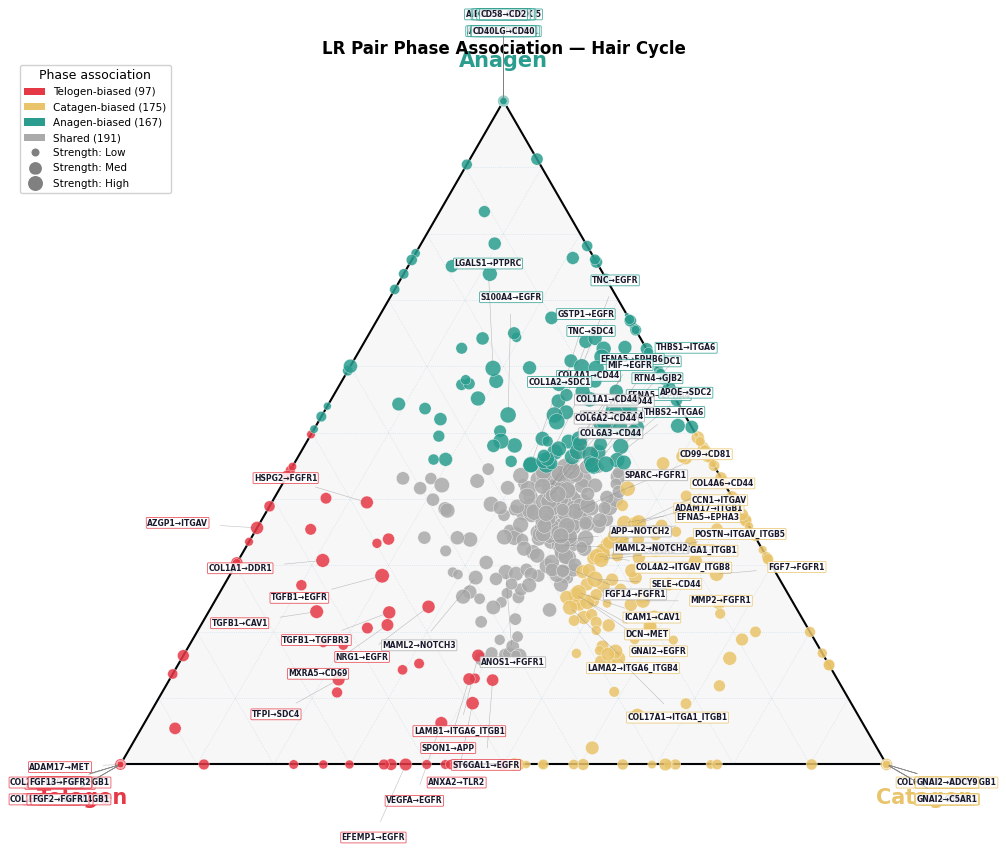

✓ Ternary plot saved.


In [20]:
import ternary
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd

fig, ax = plt.subplots(figsize=(10, 9))
ax.set_aspect("equal")
ax.axis("off")

scale = 1.0
tax = ternary.TernaryAxesSubplot(ax=ax, scale=scale)

# Use tax ONLY for triangle frame and gridlines
tax.boundary(linewidth=1.5)
tax.gridlines(alpha=0.2, linewidth=0.5, multiple=0.1)
tax.clear_matplotlib_ticks()

# --- Single projection function used for EVERYTHING ---
# Convention: Anagen=top, Catagen=bottom-right, Telogen=bottom-left
#   (ana=1, cat=0, tel=0) → (0.5, 0.866) = top         ✓
#   (ana=0, cat=1, tel=0) → (1.0, 0.0)   = bottom-right ✓
#   (ana=0, cat=0, tel=1) → (0.0, 0.0)   = bottom-left  ✓
sq3h = np.sqrt(3) / 2

def to_cart(ana, cat, tel):
    x = ana / 2.0 + cat
    y = sq3h * ana
    return x, y

# Verify
print("Verification:")
print(f"  Pure Anagen  → {to_cart(1,0,0)}")   # should be (0.5, ~0.866) = top
print(f"  Pure Catagen → {to_cart(0,1,0)}")   # should be (1.0, 0.0) = bottom-right
print(f"  Pure Telogen → {to_cart(0,0,1)}")   # should be (0.0, 0.0) = bottom-left

# --- Vertex labels ---
ax.text(0.5, sq3h + 0.04, "Anagen", ha="center", va="bottom",
        fontsize=15, fontweight="bold", color="#2A9D8F")
ax.text(1.05, -0.03, "Catagen", ha="center", va="top",
        fontsize=15, fontweight="bold", color="#E9C46A")
ax.text(-0.05, -0.03, "Telogen", ha="center", va="top",
        fontsize=15, fontweight="bold", color="#E63946")

# --- Compute cartesian positions for ALL points ---
cart_x, cart_y = to_cart(bary["ana"].values, bary["cat"].values, bary["tel"].values)

# Size
sizes = np.log1p(bary["total_strength"].values)
sizes_norm = 10 + 150 * (sizes - sizes.min()) / (sizes.max() - sizes.min())

# Color
color_map = {
    "tel": "#E63946",
    "ana": "#2A9D8F",
    "cat": "#E9C46A",
    "shared": "#AAAAAA",
}
colors = bary["category"].map(color_map).values
alpha_vals = np.clip(1 - bary["best_specificity"].values * 5, 0.25, 0.85)

# --- Plot ALL points using ax.scatter (not tax.scatter) ---
for cat_order in ["shared", "cat", "tel", "ana"]:
    mask = bary["category"].values == cat_order
    if not mask.any():
        continue
    ax.scatter(
        cart_x[mask], cart_y[mask],
        s=sizes_norm[mask],
        c=list(colors[mask]),
        alpha=alpha_vals[mask].mean(),
        edgecolors="white",
        linewidth=0.3,
        zorder=3 if cat_order != "shared" else 2,
    )

# --- Select labels ---
# --- Select labels: most phase-SPECIFIC + strongest per phase + shared + biology ---
label_candidates = pd.concat([
    # Most phase-specific (highest barycentric coordinate per phase)
    bary[bary["category"] == "tel"].nlargest(15, "tel"),
    bary[bary["category"] == "cat"].nlargest(15, "cat"),
    bary[bary["category"] == "ana"].nlargest(15, "ana"),
    # Strongest per phase (high activity, not necessarily most specific)
    bary[bary["category"] == "tel"].nlargest(15, "total_strength"),
    bary[bary["category"] == "cat"].nlargest(15, "total_strength"),
    bary[bary["category"] == "ana"].nlargest(15, "total_strength"),
    # Top shared
    bary[bary["category"] == "shared"].nlargest(5, "total_strength"),
    # Key biology
    bary[bary.index.str.contains(
        "WNT|BMP|FGF|SPP1|EDN|PDGF|NOTCH|SHH|JAG|DLL|NOG|SOST",
        case=False, na=False
    )].nlargest(8, "total_strength"),
])
label_candidates = label_candidates[~label_candidates.index.duplicated()]
print(f"Total unique labels: {len(label_candidates)}")

# --- Compute annotation positions ---
cx, cy = to_cart(1/3, 1/3, 1/3)  # centroid

label_records = []
for lr_pair, row in label_candidates.iterrows():
    px, py = to_cart(row["ana"], row["cat"], row["tel"])
    label_records.append({
        "lr_pair": lr_pair, "px": px, "py": py, "category": row["category"],
    })
label_df = pd.DataFrame(label_records)

# Radial offset from centroid
for idx, row in label_df.iterrows():
    dx = row["px"] - cx
    dy = row["py"] - cy
    dist = max(np.sqrt(dx**2 + dy**2), 1e-6)
    offset_mag = 0.07 + 0.05 * (1 - dist)
    label_df.loc[idx, "lx"] = row["px"] + offset_mag * (dx / dist)
    label_df.loc[idx, "ly"] = row["py"] + offset_mag * (dy / dist)

# Vertical stagger
for cat in label_df["category"].unique():
    cat_mask = label_df["category"] == cat
    cat_rows = label_df[cat_mask].copy().sort_values("ly")
    if len(cat_rows) > 1:
        min_gap = 0.022
        for i in range(1, len(cat_rows)):
            prev_y = cat_rows.iloc[i - 1]["ly"]
            curr_y = cat_rows.iloc[i]["ly"]
            if abs(curr_y - prev_y) < min_gap:
                cat_rows.iloc[i, cat_rows.columns.get_loc("ly")] = prev_y + min_gap
        label_df.loc[cat_rows.index] = cat_rows

# --- Annotate ---
for _, row in label_df.iterrows():
    label = row["lr_pair"].replace(" → ", "→")
    cat_color = color_map.get(row["category"], "#333333")
    ax.annotate(
        label,
        xy=(row["px"], row["py"]),
        xytext=(row["lx"], row["ly"]),
        fontsize=5.5, fontweight="bold", color="#1a1a2e",
        ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.12", facecolor="white",
                  edgecolor=cat_color, alpha=0.85, linewidth=0.6),
        arrowprops=dict(arrowstyle="-", color="grey", alpha=0.5,
                        lw=0.4, shrinkA=8, shrinkB=2),
        zorder=6,
    )

# --- Legend ---
legend_elements = [
    mpl.patches.Patch(facecolor=color_map["tel"], label=f"Telogen-biased ({(bary['category']=='tel').sum()})"),
    mpl.patches.Patch(facecolor=color_map["cat"], label=f"Catagen-biased ({(bary['category']=='cat').sum()})"),
    mpl.patches.Patch(facecolor=color_map["ana"], label=f"Anagen-biased ({(bary['category']=='ana').sum()})"),
    mpl.patches.Patch(facecolor=color_map["shared"], label=f"Shared ({(bary['category']=='shared').sum()})"),
]
for s_val, s_label in [(5, "Low"), (100, "Med"), (500, "High")]:
    s_mapped = 10 + 150 * (np.log1p(s_val) - sizes.min()) / (sizes.max() - sizes.min())
    legend_elements.append(
        mpl.lines.Line2D([0], [0], marker="o", color="w", markerfacecolor="grey",
                          markersize=np.sqrt(max(s_mapped, 1)), label=f"Strength: {s_label}"))

ax.legend(handles=legend_elements, loc="upper left", fontsize=7.5,
          framealpha=0.9, title="Phase association", title_fontsize=9,
          bbox_to_anchor=(-0.08, 1.02))

ax.set_title("LR Pair Phase Association — Hair Cycle",
             fontsize=12, fontweight="bold", pad=15)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "ternary_LR_phase_association.pdf"),
            dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(OUT_DIR, "ternary_LR_phase_association.png"),
            dpi=300, bbox_inches="tight")
plt.show()
print("✓ Ternary plot saved.")